# How to: Use Callbacks

Callbacks let you inject custom logic at well-defined points in a phase lifecycle
without subclassing the phase itself. They are attached to a `TrainPhase`,
`EvalPhase`, or `FitPhase` and are called automatically at each lifecycle boundary.

> **Note:** This notebook covers **phase-level** callbacks (`Callback` subclasses)
> that fire at batch/epoch boundaries inside a single phase. Experiment-level
> callbacks (`ExperimentCallback`) that fire at phase/group boundaries are covered
> in {doc}`05_create_experiment`.

This notebook covers:

- {ref}`08-callbacks-lifecycle`
- {ref}`08-callbacks-custom`
- {ref}`08-callbacks-evaluation`
- {ref}`08-callbacks-eval-loss-metric`
- {ref}`08-callbacks-accessing-results`
- {ref}`08-callbacks-artifact-result`
- {ref}`08-callbacks-summary`

In [1]:
%matplotlib inline
import numpy as np

from modularml import (
    AppliedLoss,
    EvalPhase,
    Experiment,
    FeatureSet,
    Loss,
    ModelGraph,
    ModelNode,
    Optimizer,
    TrainPhase,
)
from modularml.models.torch import SequentialMLP
from modularml.samplers import SimpleSampler

## Experiment Setup

We set up a small synthetic experiment used throughout this notebook.
The setup follows the pattern from {doc}`05_create_experiment`.

In [2]:
rng = np.random.default_rng(42)

# Synthetic data: 500 samples, 20-d feature, 1-d target
fs = FeatureSet.from_dict(
    label="SensorData",
    data={
        "voltage": list(rng.standard_normal((500, 20))),
        "soh": list(rng.standard_normal((500, 1))),
    },
    feature_keys="voltage",
    target_keys="soh",
)
fs.split_random(ratios={"train": 0.7, "val": 0.15, "test": 0.15}, seed=13)
fs_ref = fs.reference(features="voltage", targets="soh")

mn_mlp = ModelNode(
    label="MLP",
    model=SequentialMLP(output_shape=(1, 1), n_layers=2, hidden_dim=16),
    upstream_ref=fs_ref,
)
graph = ModelGraph(
    label="SimpleGraph",
    nodes=[mn_mlp],
    optimizer=Optimizer("adam", opt_kwargs={"lr": 1e-3}, backend="torch"),
)
graph.build()

exp = Experiment.from_active_context(label="my_experiment")

mse_loss = AppliedLoss(
    loss=Loss("mse", backend="torch"),
    on="MLP",
    inputs=["outputs", "targets"],
)
print(f"Splits: {fs.available_splits}")

Splits: ['train', 'val', 'test']


---

(08-callbacks-lifecycle)=
## The Callback Lifecycle

Every `Callback` subclass can override up to seven hook methods. They are called
automatically by the phase in the order shown below:

```
on_phase_start
  for each epoch:
    on_epoch_start
      for each batch:
        on_batch_start
        [forward / backward pass]
        on_batch_end
    on_epoch_end
on_phase_end

on_exception  # called if any hook or step raises
```

| Hook | Signature | When it fires |
|------|-----------|---------------|
| `on_phase_start` | `(experiment, phase, results)` | Once before the first epoch |
| `on_phase_end` | `(experiment, phase, results)` | Once after the last epoch |
| `on_epoch_start` | `(experiment, phase, exec_ctx, results)` | Before each epoch's first batch |
| `on_epoch_end` | `(experiment, phase, exec_ctx, results)` | After each epoch's last batch |
| `on_batch_start` | `(experiment, phase, exec_ctx, results)` | Before each batch |
| `on_batch_end` | `(experiment, phase, exec_ctx, results)` | After each batch |
| `on_exception` | `(experiment, phase, exec_ctx, exception, results)` | On any unhandled exception |

Each hook may return any value (or `None`). Non-`None` return values are automatically
wrapped in a `CallbackResult` and stored in the phase's `PhaseResults` container,
keyed by the callback's label.

---

(08-callbacks-custom)=
## Writing a Custom Callback

Subclass `Callback` and override only the hooks you need. The only abstract
requirement is implementing `get_config()` and `from_config()` for serialization.

The example below prints the mean training loss at the end of every epoch.

In [3]:
from typing import Any

from modularml.core.experiment.callbacks.callback import Callback


class LossLogger(Callback):
    """Prints the mean training loss at the end of each epoch."""

    def __init__(self, node: str = "MLP", label: str | None = None):
        super().__init__(label=label or "LossLogger")
        self.node = node
        self._epoch_losses: list[float] = []

    def on_epoch_end(self, *, experiment, phase, exec_ctx, results=None):
        epoch_idx = exec_ctx.epoch_idx
        # Use the results provided to this hook
        if results is not None:
            # Grab the recorded losses for this epoch
            epoch_losses = results.losses(node=self.node).where(epoch=epoch_idx)

            # Since we likely have a loss recorded for each batch in the epoch,
            # we can collapse losses via averaging
            if len(epoch_losses.values()) > 0:
                collapsed = epoch_losses.collapse(axis="batch", reducer="mean").one()
                # Grab the trainable component of this loss
                loss_val = collapsed.trainable
                self._epoch_losses.append(loss_val)
                print(f"  epoch {epoch_idx:>3}: train_loss = {loss_val:.4f}")

    def get_config(self) -> dict[str, Any]:
        return {"callback_type": self.__class__.__name__, "node": self.node, "label": self.label}

    @classmethod
    def from_config(cls, config: dict) -> "LossLogger":
        return cls(node=config["node"], label=config["label"])

Callbacks are registered on a phase via `add_callback()` or at construction time
via the `callbacks=` parameter.

In [4]:
loss_logger = LossLogger(node="MLP")

train_phase = TrainPhase.from_split(
    label="train",
    split="train",
    sampler=SimpleSampler(batch_size=32, shuffle=True, seed=42),
    losses=[mse_loss],
    n_epochs=3,
    callbacks=[loss_logger],
)
print(f"Attached callbacks: {[cb.label for cb in train_phase.callbacks]}")

Attached callbacks: ['LossLogger']


In [5]:
train_results = exp.run_phase(train_phase)

Output()

epoch   0: train_loss = 0.9862

epoch   1: train_loss = 0.9457

epoch   2: train_loss = 0.9182

In [6]:
print(f"\nRecorded epoch losses: {loss_logger._epoch_losses}")


Recorded epoch losses: [0.9861669811335477, 0.9457106644457037, 0.9182447140867059]


### `ExecutionContext`

In addition to the current phase results, epoch- and batch-level hooks
receive an `ExecutionContext` (`exec_ctx`) with the following fields:

| Field | Type | Description |
|-------|------|-------------|
| `phase_label` | `str` | Label of the currently executing phase |
| `epoch_idx` | `int \| None` | Zero-based epoch index (`None` in `EvalPhase`) |
| `batch_idx` | `int` | Zero-based batch index within the epoch |
| `inputs` | `dict` | Pre-materialized input batches for all head nodes |

---

(08-callbacks-evaluation)=
## The `Evaluation` Built-in Callback

`Evaluation` runs a full `EvalPhase` at configurable epoch intervals and stores
the resulting `EvalResults` as an `EvaluationCallbackResult`. It is the primary
tool for tracking held-out performance during training.

```python
    Evaluation(
        eval_phase: EvalPhase,
        every_n_epochs: int = 1,
        run_on_start: bool = False,
        label: str | None = None,
        metrics: list[EvaluationMetric] | None = None,
    )
```

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `eval_phase` | `EvalPhase` | (required) | The evaluation phase to run. |
| `every_n_epochs` | `int` | `1` | Run evaluation every N completed epochs. |
| `run_on_start` | `bool` | `False` | If `True`, also evaluate before epoch 0. |
| `label` | `str \| None` | `None` | Result key (defaults to `eval_phase.label`). |
| `metrics` | `list[EvaluationMetric]` | `None` | Metric extractors to run after each evaluation. |

A convenience constructor `Evaluation.from_split()` creates the inner `EvalPhase`
automatically:

In [7]:
from modularml.callbacks import Evaluation

eval_cb = Evaluation.from_split(
    label="eval_val",
    split="val",
    every_n_epochs=1,
)

train_phase_with_eval = TrainPhase.from_split(
    label="train_with_eval",
    split="train",
    sampler=SimpleSampler(batch_size=32, shuffle=True, seed=42),
    losses=[mse_loss],
    n_epochs=3,
    callbacks=[eval_cb],
)

train_results = exp.run_phase(train_phase_with_eval)
print("Training with Evaluation callback complete.")

Output()

Training with Evaluation callback complete.

### How `Evaluation` Works

`Evaluation` fires in `on_epoch_end`. At each selected epoch it calls
`experiment.preview_phase(phase=self.eval_phase)`, a stateless forward pass
that does **not** mutate experiment history or optimizer state.

The evaluation result is wrapped in an `EvaluationCallbackResult` and stored
in the `TrainResults` of the parent `TrainPhase`, keyed by the callback label.

In [9]:
print(train_results.callbacks())

eval_cbs = train_results.callbacks(kind="evaluation").values()
print(eval_cbs)

CallbackDataSeries(keyed_by=('kind', 'label', 'epoch', 'batch', 'edge'), len=3)
[EvaluationCallbackResult(callback_label='eval_val', phase_label='train_with_eval', epoch_idx=0, batch_idx=None, edge='end', eval_results=EvalResults(label='eval_val', batches=1)), EvaluationCallbackResult(callback_label='eval_val', phase_label='train_with_eval', epoch_idx=1, batch_idx=None, edge='end', eval_results=EvalResults(label='eval_val', batches=1)), EvaluationCallbackResult(callback_label='eval_val', phase_label='train_with_eval', epoch_idx=2, batch_idx=None, edge='end', eval_results=EvalResults(label='eval_val', batches=1))]


In [10]:
# And the eval results in those callbacks can be accessed with
[eval_cb.eval_results for eval_cb in eval_cbs]

[EvalResults(label='eval_val', batches=1),
 EvalResults(label='eval_val', batches=1),
 EvalResults(label='eval_val', batches=1)]

While running evaluation on some set of data during callbacks can be useful,
a more common case is to record metrics on an evaluation forward pass.

This is where `EvaluationMetric` and `EvalLossMetric` come in.
It is equivalent to defining an `Evaluation` callback with an attached loss; however,
`MetricCallback`s provide more-convenient access to scalar values produced by callback hooks.

(08-callbacks-eval-loss-metric)=
## The `EvalLossMetric` Built-in Metric

`EvalLossMetric` is an `EvaluationMetric` that extracts a scalar loss value
from an `Evaluation` result and logs it to the `MetricStore` under a chosen name
(default: `"val_loss"`). Pass it to `Evaluation` via the `metrics=` argument.

```python
    EvalLossMetric(
        loss: AppliedLoss,
        reducer: Literal["sum", "mean"] = "mean",
        name: str = "val_loss",
    )
```

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `loss` | `AppliedLoss` | (required) | Applied loss to track. Appended to the inner `EvalPhase` automatically if not already present. |
| `reducer` | `str` | `"mean"` | How to aggregate per-batch losses into a scalar. |
| `name` | `str` | `"val_loss"` | Metric name logged to the `MetricStore`. |

In [11]:
from modularml.callbacks import EvalLossMetric, Evaluation

# We define a loss to be applied during our Evaluation callback
val_loss_metric = EvalLossMetric(
    loss=AppliedLoss(
        loss=Loss("mse", backend="torch"),
        on="MLP",
        inputs=["targets", "outputs"],
    ),
    reducer="mean",
    name="val_loss",
)
# ^ note that metrics with name "val_loss" will be shown in the progress bars during training

eval_cb_with_metric = Evaluation.from_split(
    label="eval_val",
    split="val",
    every_n_epochs=1,
    metrics=[val_loss_metric],
)

train_phase_tracked = TrainPhase.from_split(
    label="train_tracked",
    split="train",
    sampler=SimpleSampler(batch_size=32, shuffle=True, seed=42),
    losses=[mse_loss],
    n_epochs=5,
    callbacks=[eval_cb_with_metric],
)

train_results = exp.run_phase(train_phase_tracked)
print("Training complete.")

Output()

Training complete.

---

(08-callbacks-accessing-results)=
## Accessing Callback Results

After training, callback results are stored in the parent phase under a `callbacks` attribute.

Metrics are available under the `metrics` attribute.

In [ ]:
# Here we grab the training results directly from the experiment's history
last_train_results = exp.last_run.results

# All result attributes return AxisSeries; it's essentially a queriable, multi-keyed dict
# More on those in a later notebook
val_losses = last_train_results.metrics().where(name="val_loss").values()
print("val_loss per epoch:")
for entry in val_losses:
    print(f"  epoch {entry.epoch_idx}: {entry.value:.4f}")

val_loss per epoch:
  epoch 0: 1.2801
  epoch 1: 1.2810
  epoch 2: 1.2825
  epoch 3: 1.2844
  epoch 4: 1.2866


Full Evaluation results are a little more annoying to access as all values returned by a callback hook are wrapped in a CallbackResult container.

For callbacks that run an EvalPhase, our data structure is along the lines of:

> CallbackResults --> EvalResults --> [tensors, losses, metrics]

In [13]:
print(last_train_results.callbacks().axes)

print("Axis values:")
for k, vs in last_train_results.callbacks().axes_values().items():
    print(f"  {k}: {vs}")

# Grab the underlying EvalResults from epoch 3
cb_res = last_train_results.callbacks(kind="evaluation").where(epoch=3).one()
print(cb_res.eval_results)

# Output tensors accessed directly
pred = cb_res.stacked_tensors(node="MLP", domain="outputs", fmt="np").reshape(-1)
true = cb_res.stacked_tensors(node="MLP", domain="targets", fmt="np").reshape(-1)

('kind', 'label', 'epoch', 'batch', 'edge')
Axis values:
  kind: ['evaluation']
  label: ['eval_val']
  epoch: [0, 1, 2, 3, 4]
  batch: [None]
  edge: ['end']
EvalResults(label='eval_val', batches=1)


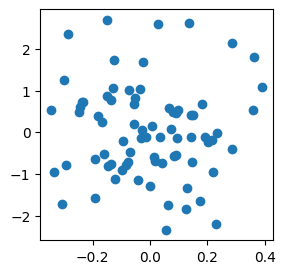

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.scatter(pred, true)
plt.show()

*Pretty terrible results :(*

But at least we can run callbacks.

---

(08-callbacks-artifact-result)=
## The `ArtifactResult` - logging rich non-scalar objects

`MetricResult` is restricted to scalar return types.
For richer objects (e.g., matplotlib figures, pandas DataFrames, numpy arrays, text), wrap your custom callback returns in an `ArtifactResult`.

```python
    ArtifactResult(
        artifact_name: str,   # stable name, e.g. "val_scatter"
        artifact: Any,        # any Python object
    )
```

When an `ArtifactResult` is returned, the framework:
1. Stores the result in `PhaseResults._callbacks` (accessible via `callbacks(kind="artifact")`)
2. **Also** stores it in `PhaseResults._artifacts` (accessible via `results.artifacts()`)

This provides more convenient access to artifacts, similar to the access path of metrics.

If the `Experiment` was created with a `ResultsConfig(results_dir=...)`, the artifact is
serialized to disk automatically. `entry.artifact` transparently deserializes it on access.

Let's create a custom callback that produces matplotlib figures at the end of each epoch.

In [15]:
import matplotlib.pyplot as plt

from modularml.callbacks import ArtifactResult


class ScatterPlotCallback(Callback):
    """Produces a pred-vs-true scatter plot at the end of every epoch."""

    def __init__(self, node: str = "MLP", label: str | None = None):
        super().__init__(label=label or "ScatterPlot")
        self.node = node

    def on_epoch_end(self, *, experiment, phase, exec_ctx, results=None):
        # Only run every other epoch to keep the demo quick
        if exec_ctx.epoch_idx % 2 != 0:
            return None

        # Pull predictions from the most recent eval callback result
        if results is None:
            return None
        eval_cbs = results.callbacks(kind="evaluation").values()
        if not eval_cbs:
            return None
        last_eval = eval_cbs[-1]

        pred = last_eval.stacked_tensors(node=self.node, domain="outputs", fmt="np").reshape(-1)
        true = last_eval.stacked_tensors(node=self.node, domain="targets", fmt="np").reshape(-1)

        fig, ax = plt.subplots(figsize=(3, 3))
        ax.scatter(pred, true, alpha=0.4, s=10)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(f"Epoch {exec_ctx.epoch_idx}")
        plt.tight_layout()
        plt.close()

        return ArtifactResult(artifact_name="val_scatter", artifact=fig)

    def get_config(self):
        return {"callback_type": self.__class__.__name__, "node": self.node, "label": self.label}

    @classmethod
    def from_config(cls, config):
        return cls(node=config["node"], label=config["label"])


scatter_cb = ScatterPlotCallback(node="MLP")
eval_cb_for_scatter = Evaluation.from_split(
    label="eval_val",
    split="val",
    every_n_epochs=1,
)

train_phase_with_artifacts = TrainPhase.from_split(
    label="train_with_artifacts",
    split="train",
    sampler=SimpleSampler(batch_size=32, shuffle=True, seed=42),
    losses=[mse_loss],
    n_epochs=4,
    callbacks=[eval_cb_for_scatter, scatter_cb],
)

train_results = exp.run_phase(train_phase_with_artifacts)
print("Artifact names:", train_results.artifact_names())

Output()

Artifact names: ['val_scatter']

Artifact names: ['val_scatter']
Scatter plots recorded: 2
  epoch 0: Figure
  epoch 2: Figure


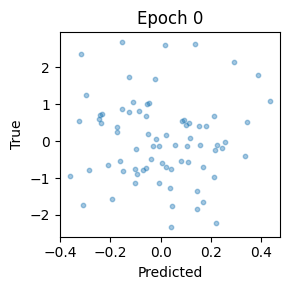

In [16]:
# List all artifact names produced during the phase
print("Artifact names:", train_results.artifact_names())

# Query via the artifact store; keyed by (name, epoch, batch)
scatter_series = train_results.artifacts().where(name="val_scatter")
print(f"Scatter plots recorded: {len(scatter_series)}")
for entry in scatter_series.values():
    print(f"  epoch {entry.epoch_idx}: {type(entry.artifact).__name__}")

# entry.artifact transparently loads from disk when ResultsConfig(results_dir=...) is set
entry = scatter_series.where(epoch=0).one()
entry.artifact

(08-callbacks-summary)=
## Summary

### `Callback` Base Class

| Method | Override to... |
|--------|----------------|
| `on_phase_start(experiment, phase, results)` | Run once before the first epoch. |
| `on_phase_end(experiment, phase, results)` | Run once after the last epoch. |
| `on_epoch_start(experiment, phase, exec_ctx, results)` | Run before each epoch. |
| `on_epoch_end(experiment, phase, exec_ctx, results)` | Run after each epoch. |
| `on_batch_start(experiment, phase, exec_ctx, results)` | Run before each batch. |
| `on_batch_end(experiment, phase, exec_ctx, results)` | Run after each batch. |
| `on_exception(experiment, phase, exec_ctx, exception, results)` | Run on unhandled exception. |
| `get_config()` | Serialize callback config (required). |
| `from_config(config)` | Reconstruct from config (required). |

### `Evaluation` Callback

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `eval_phase` | `EvalPhase` | (required) | Phase to run on selected epochs. |
| `every_n_epochs` | `int` | `1` | Evaluation frequency. |
| `run_on_start` | `bool` | `False` | Evaluate before training begins. |
| `label` | `str \| None` | `None` | Result key (defaults to phase label). |
| `metrics` | `list[EvaluationMetric]` | `None` | Metric extractors run after each evaluation. |

Convenience constructor: `Evaluation.from_split(label, split, losses, every_n_epochs, metrics, ...)`

### `EvalLossMetric`

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `loss` | `AppliedLoss` | (required) | Applied loss to track. |
| `reducer` | `str` | `"mean"` | Batch aggregation method. |
| `name` | `str` | `"val_loss"` | Metric name in the `MetricStore`. |

### `ArtifactResult`

Return an `ArtifactResult` from any callback hook to log a rich non-scalar object
(matplotlib figure, DataFrame, array, text, …).

| Field | Type | Description |
|-------|------|-------------|
| `artifact_name` | `str` | Stable name for querying (e.g. `"val_scatter"`). |
| `artifact` | `Any` | The object to store. |

### Accessing Results

| Expression | Returns | Notes |
|------------|---------|-------|
| `results.metrics().where(name="val_loss")` | `AxisSeries[MetricEntry]` | Scalar metrics keyed by `(name, epoch, batch)`. |
| `results.callbacks()` | `CallbackDataSeries` | All callback results keyed by `(kind, label, epoch, batch, edge)`. |
| `results.callbacks(kind="evaluation")` | `AxisSeries[EvaluationCallbackResult]` | Type-narrowed to evaluation results. |
| `results.callbacks(kind="metric")` | `AxisSeries[MetricResult]` | Type-narrowed to metric results. |
| `results.callbacks(kind="artifact")` | `AxisSeries[ArtifactResult]` | Type-narrowed to artifact results. |
| `results.callbacks(kind="payload")` | `AxisSeries[PayloadResult]` | Type-narrowed to arbitrary payload results. |
| `results.artifacts()` | `ArtifactDataSeries` | Artifact entries keyed by `(name, epoch, batch)`. |
| `results.artifact_names()` | `list[str]` | All unique artifact names recorded. |
| `entry.artifact` | `Any` | The artifact object; auto-loads from disk if serialized via `ResultsConfig`. |
| `cb.stacked_tensors(node, domain, fmt)` | `np.ndarray \| Tensor` | Concatenated tensors across all eval batches. |
| `cb.aggregated_losses(node, reducer)` | `dict[str, float]` | Per-loss scalar dict. |

### Results Storage

`ResultsConfig` controls where artifacts and execution contexts are stored (RAM vs disk).
See {doc}`05_create_experiment` for the full `ResultsConfig` and `ResultRecording` reference.

### Next Steps

- **Cross-validation:** Use `Evaluation` and `EvalLossMetric` together with
  `CrossValidation` and `CVBinding`; see {doc}`09_use_cross_validation`